In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from tensorflow import keras
import matplotlib.pyplot as plt

In [9]:
dataset = pd.read_csv('mushrooms.csv')
dataset.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


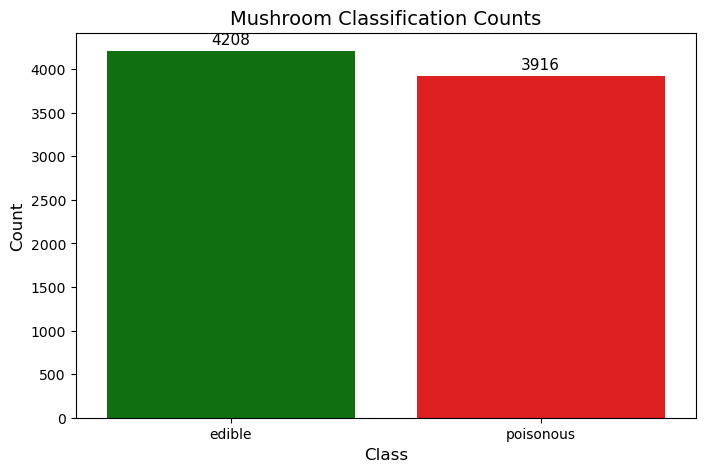

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (ensure the file is in the correct directory or provide the full path)
dataset = pd.read_csv('mushrooms.csv')

# Count the occurrences of each class
class_counts = dataset['class'].value_counts()

# Create a DataFrame for plotting
class_data = pd.DataFrame({'class': ['edible', 'poisonous'], 'count': class_counts.values})

# Add a hue column to differentiate classes
class_data['hue'] = class_data['class']

# Define custom colors for the classes
custom_palette = {'edible': 'green', 'poisonous': 'red'}

# Plotting the barplot with hue
plt.figure(figsize=(8, 5))  # Set the figure size
ax = sns.barplot(data=class_data, x='class', y='count', hue='hue', palette=custom_palette, dodge=False)

# Annotate bars with the actual count values
for bar in ax.patches:
    count = int(bar.get_height())  # Get the height of the bar (integer count)
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, count),
                xytext=(0, 5),  # Offset annotation slightly above the bar
                textcoords='offset points', ha='center', fontsize=11, color='black')

# Adding labels and title
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Mushroom Classification Counts', fontsize=14)

# Display the plot
plt.show()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (ensure the file is in the correct directory or provide the full path)
dataset = pd.read_csv('mushrooms.csv')

# Count the occurrences of each class
class_counts = dataset['class'].value_counts()

# Create a DataFrame for plotting
class_data = pd.DataFrame({'class': ['edible', 'poisonous'], 'count': class_counts.values})

# Add a hue column to differentiate classes
class_data['hue'] = class_data['class']

# Define custom colors for the classes
custom_palette = {'edible': 'green', 'poisonous': 'red'}

# Plotting the barplot with hue
plt.figure(figsize=(8, 5))  # Set the figure size
ax = sns.barplot(data=class_data, x='class', y='count', hue='hue', palette=custom_palette, dodge=False)

# Annotate bars with the actual count values
for bar in ax.patches:
    count = int(bar.get_height())  # Get the height of the bar (integer count)
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, count),
                xytext=(0, 5),  # Offset annotation slightly above the bar
                textcoords='offset points', ha='center', fontsize=11, color='black')

# Adding labels and title
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Mushroom Classification Counts', fontsize=14)

# Display the plot
plt.show()


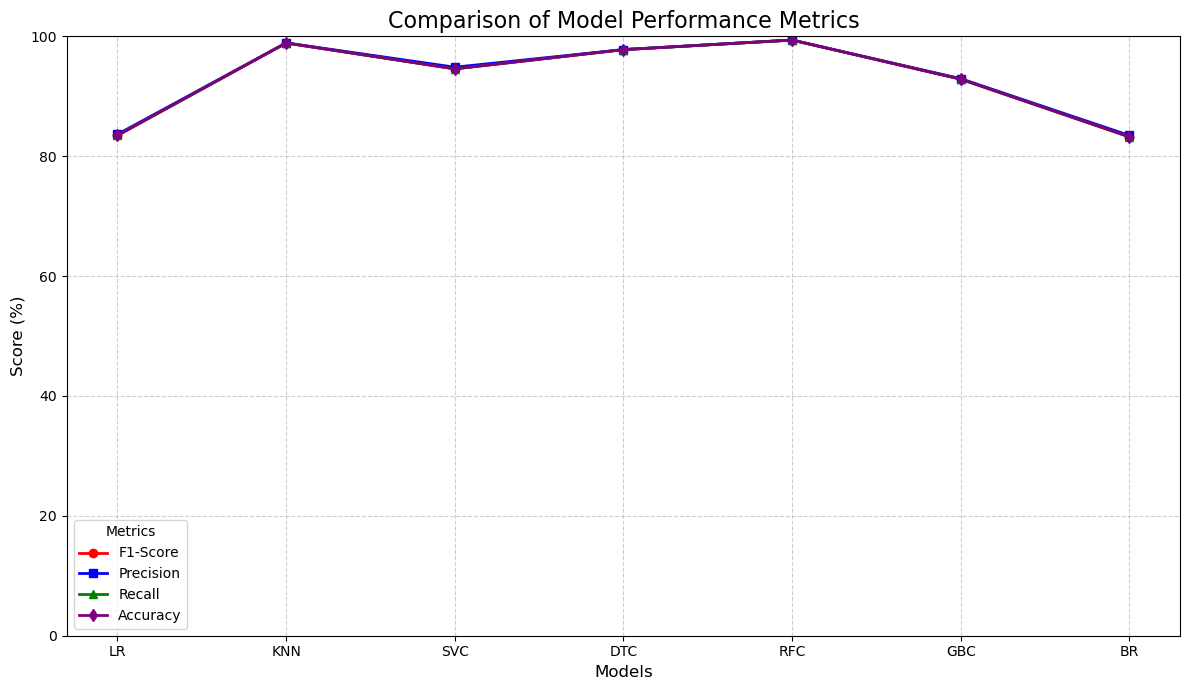

In [15]:
import matplotlib.pyplot as plt

# Define models and metrics
models = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']
f1_score = [83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21]
precision = [83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46]
recall = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]
accuracy = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]

# Plot each metric with different colors and markers
plt.figure(figsize=(12, 7))
plt.plot(models, f1_score, marker='o', color='red', label='F1-Score', linewidth=2)
plt.plot(models, precision, marker='s', color='blue', label='Precision', linewidth=2)
plt.plot(models, recall, marker='^', color='green', label='Recall', linewidth=2)
plt.plot(models, accuracy, marker='d', color='purple', label='Accuracy', linewidth=2)

# Add labels, title, legend, and grid
plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.ylim(0, 100)  # Assuming percentages
plt.legend(title="Metrics")
plt.grid(True, linestyle='--', alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()




In [3]:
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split

# Assuming the dataset is already split into training, validation, and test sets
# You can use the models you've trained earlier for this
models = [
    LogisticRegression(),
    KNeighborsClassifier(),
    SVC(probability=True),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    BernoulliNB()
]

model_names = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']

# Initialize plot
plt.figure(figsize=(10, 6))

# For each model, calculate and plot the ROC curve
for model, name in zip(models, model_names):
    # Train the model on the training data
    model.fit(x_train, y_train)

    # Predict probabilities for the positive class
    y_prob = model.predict_proba(x_test)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the diagonal line representing random guessing (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')

# Add labels and title
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()


NameError: name 'x_train' is not defined

<Figure size 1000x600 with 0 Axes>

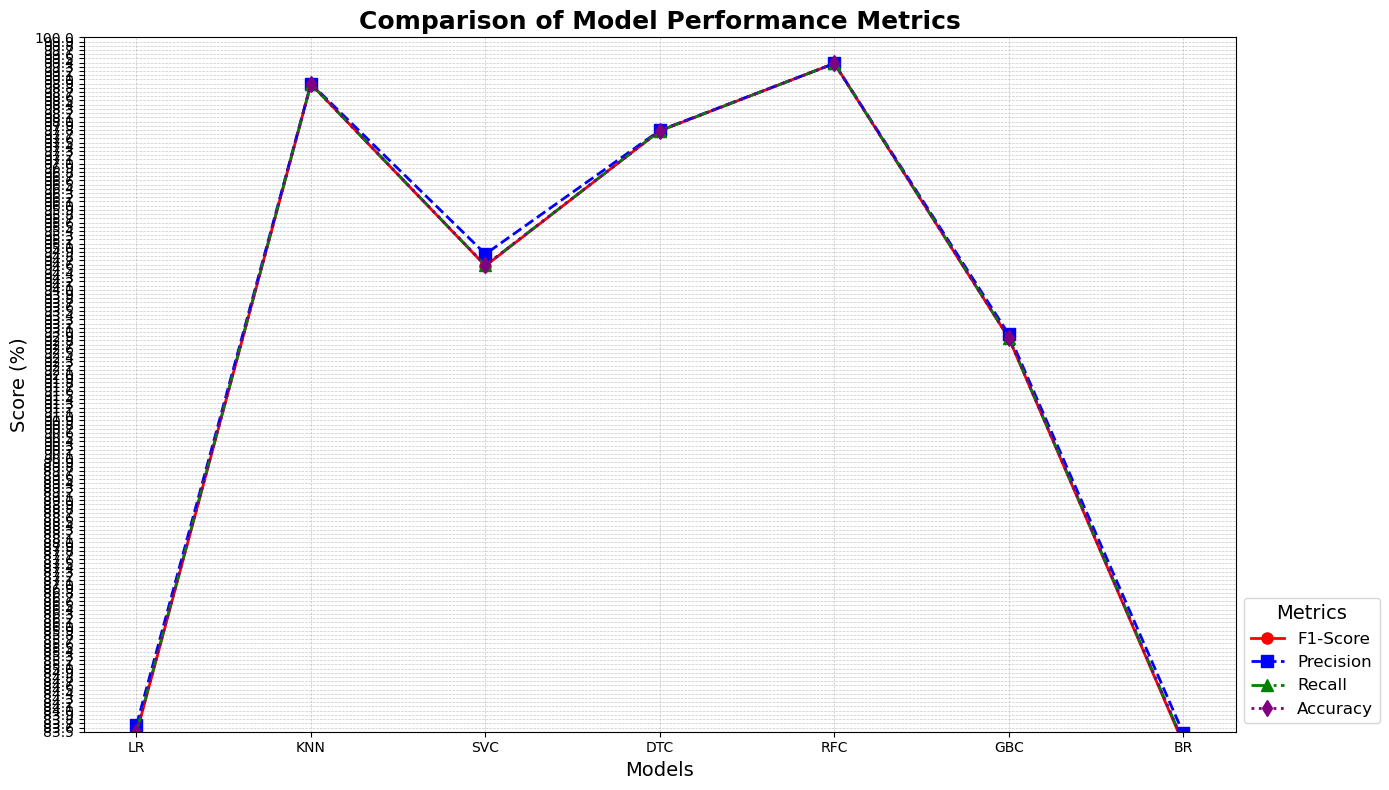

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define models and metrics
models = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']
f1_score = [83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21]
precision = [83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46]
recall = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]
accuracy = [83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25]

# Plot each metric with distinct colors, line styles, and markers
plt.figure(figsize=(14, 8))
plt.plot(models, f1_score, marker='o', color='red', label='F1-Score', linewidth=2, markersize=8, linestyle='-')
plt.plot(models, precision, marker='s', color='blue', label='Precision', linewidth=2, markersize=8, linestyle='--')
plt.plot(models, recall, marker='^', color='green', label='Recall', linewidth=2, markersize=8, linestyle='-.')
plt.plot(models, accuracy, marker='d', color='purple', label='Accuracy', linewidth=2, markersize=8, linestyle=':')

# Add labels, title, and legend
plt.title('Comparison of Model Performance Metrics', fontsize=18, fontweight='bold')
plt.xlabel('Models', fontsize=14)
plt.ylabel('Score (%)', fontsize=14)

# Define a clean y-axis range with finer intervals
y_ticks = np.arange(83.50, 100.1, 0.1)
plt.yticks(y_ticks, fontsize=10)
plt.ylim(83.50, 100)

# Add legend with a larger title for clarity
plt.legend(title="Metrics", fontsize=12, title_fontsize=14, loc='lower left', bbox_to_anchor=(1, 0))

# Add grid with enhanced visibility
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Ensure better spacing around the plot
plt.tight_layout()

# Show the plot
plt.show()



In [7]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Initialize the models (same as before)
models = [
    LogisticRegression(),
    KNeighborsClassifier(),
    SVC(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    BernoulliNB()
]

model_names = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']

# Initialize a list to store the mean cross-validation scores
cv_scores = []

# For each model, perform cross-validation and get the mean score
for model in models:
    cv_score = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
    cv_scores.append(cv_score.mean())

# Create a bar plot to visualize cross-validation scores
plt.figure(figsize=(10, 6))
plt.bar(model_names, cv_scores, color='skyblue')
plt.xlabel('Models', fontsize=12)
plt.ylabel('Mean Cross-Validation Score (%)', fontsize=12)
plt.title('Cross-Validation Scores of Different Models', fontsize=16)
plt.ylim(0, 1)  # The score is between 0 and 1
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

# Optionally, print out the cross-validation scores for each model
for name, score in zip(model_names, cv_scores):
    print(f"{name}: {score * 100:.2f}%")


NameError: name 'x_train' is not defined

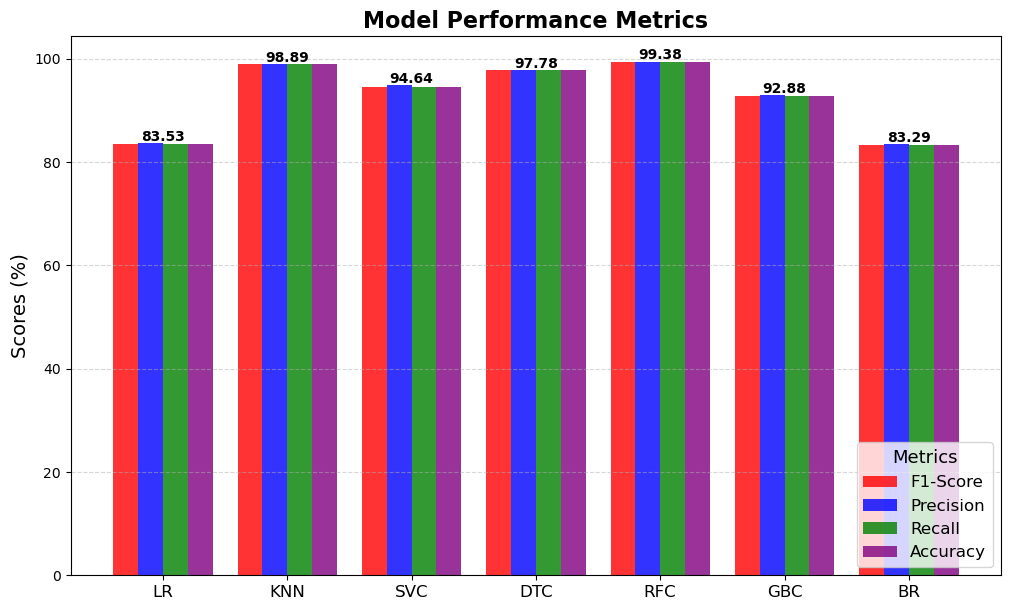

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['LR', 'KNN', 'SVC', 'DTC', 'RFC', 'GBC', 'BR']
f1_score = np.array([83.46, 98.89, 94.57, 97.78, 99.38, 92.85, 83.21])
precision = np.array([83.66, 98.90, 94.85, 97.79, 99.38, 92.94, 83.46])
recall = np.array([83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25])
accuracy = np.array([83.50, 98.89, 94.58, 97.78, 99.38, 92.86, 83.25])

# Calculate average scores
average_scores = (f1_score + precision + recall + accuracy) / 4

# Define bar width and x-axis positions
bar_width = 0.2
x = np.arange(len(models))

# Set up figure
plt.figure(figsize=(12, 7))

# Plot each metric with distinct colors
plt.bar(x - 1.5 * bar_width, f1_score, width=bar_width, label='F1-Score', color='red', alpha=0.8)
plt.bar(x - 0.5 * bar_width, precision, width=bar_width, label='Precision', color='blue', alpha=0.8)
plt.bar(x + 0.5 * bar_width, recall, width=bar_width, label='Recall', color='green', alpha=0.8)
plt.bar(x + 1.5 * bar_width, accuracy, width=bar_width, label='Accuracy', color='purple', alpha=0.8)

# Add labels, title, and grid
plt.xticks(x, models, fontsize=12)
plt.ylabel('Scores (%)', fontsize=14)
plt.title('Model Performance Metrics', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate bars with average score per algorithm
for i in range(len(models)):
    plt.text(x[i], max(f1_score[i], precision[i], recall[i], accuracy[i]) + 0.5,  
             f"{average_scores[i]:.2f}", fontsize=10, color='black', ha='center', fontweight='bold')

# Add legend
plt.legend(title="Metrics", fontsize=12, title_fontsize=13, loc='lower right')

# Show plot
plt.show()



In [13]:
x= dataset.drop('class',axis=1)
y =dataset["class"]

NameError: name 'dataset' is not defined

In [9]:
from sklearn.decomposition import PCA
pca1 =PCA(n_components=5)
pca_fit = pca1.fit_transform(x)

NameError: name 'x' is not defined

In [13]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define a simple neural network
model = Sequential([
    Dense(16, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # Assuming binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model and record the loss history
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), batch_size=16, verbose=1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.show()



NameError: name 'x_train' is not defined

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'X' is not defined

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters for each model
param_grid_rf = {
    'n_estimators': [50, 100, 300,500],
    'max_depth': [None, 10, 20, 50,100],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 2, 4,10],
    'bootstrap': [True, False]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

param_grid_dtc = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Define models
models = {
    'RFC': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'DTC': DecisionTreeClassifier()
}

# Perform GridSearchCV for each model
best_models = {}

for name, model in models.items():
    print(f"Running GridSearchCV for {name}...")
    
    # Select the appropriate parameter grid
    if name == 'RFC':
        param_grid = param_grid_rf
    elif name == 'KNN':
        param_grid = param_grid_knn
    elif name == 'DTC':
        param_grid = param_grid_dtc

    # Perform GridSearchCV
    #grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
    random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_grid_rf,
    n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1
)
   # grid_search.fit(x_train, y_train)
    print(f"Cross-validated score for {name}: {grid_search.best_score_:.4f}")

    # Save the best model for later use
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")

# Print the best models found by GridSearchCV
for name, best_model in best_models.items():
    print(f"Best Model for {name}: {best_model}")